# US Firm Characteristics: Feature Engineering

This notebook constructs the feature matrix for the cross-sectional factor
investing case study. It preserves the provider's split-scoped firm identity
and organizes the released characteristics into economic families.

## Learning Objectives

- Map pre-computed Chen-Pelger-Zhu characteristics to economic factor families
- Preserve the released anonymous firm identity across monthly observations
- Construct composite factor scores (value + quality, value + momentum)
- Evaluate feature quality before the holdout via monthly information coefficients
- Apply HAC uncertainty and false-discovery control to feature diagnostics

## Book Reference

Chapter 8, Section 8.4 (Contextual and Slow-Moving Features)

## Prerequisites

- [`02_labels`](02_labels.ipynb) must have been run (produces labels and cv_config)
- Firm characteristics data available via `load_firm_characteristics()`

## Key Insight

The Chen-Pelger-Zhu dataset provides characteristics *already* cross-sectionally
rank-transformed to $[-0.5, 0.5]$. This means the raw columns are effectively
percentile ranks. Our feature engineering focuses on:
1. **Preservation**: Carrying all 46 released characteristics into the model matrix
2. **Interactions**: Adding economically motivated composites and products
3. **Documentation**: Mapping each column to an economic factor family

## Cost Structure Note

Transaction costs are era-dependent for this dataset:
- **Pre-2001** (pre-decimalization): 15-30 bps/leg for mid-caps
- **Post-2001**: 5-15 bps/leg
- **Borrow costs** (short leg): 25-100 bps/yr general collateral; up to 500+ bps for specials
- See D'Avolio (2002) for borrow cost documentation

In [1]:
"""US Firm Characteristics: Feature Engineering."""

import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr
from ml4t.diagnostic.metrics import compute_ic_hac_stats

from data import load_firm_characteristics
from utils.paths import display_path, get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title, zero_line

warnings.filterwarnings("ignore")

CASE_DIR = get_case_study_dir("us_firm_characteristics")
FEATURES_DIR = CASE_DIR / "features"
LABELS_DIR = CASE_DIR / "labels"
SETUP = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

In [2]:
CASE_STUDY_ID = "us_firm_characteristics"
START_DATE = "1990-01-01"
MAX_SYMBOLS = 0

## 1. Load Data and Labels

We load the released characteristics and retain the converter's `symbol` field.
It represents a stable anonymous firm axis within each source tensor block. All
model-development folds and the sealed 2016 holdout fall in the same test block,
so longitudinal histories are meaningful throughout the study window.

In [3]:
firm_chars = load_firm_characteristics(split="all").with_columns(pl.col("timestamp").cast(pl.Date))

START_DATE = "1990-01-01"
END_DATE = "2016-12-31"

firm_chars = firm_chars.filter(
    (pl.col("timestamp") >= pl.lit(START_DATE).str.to_date())
    & (pl.col("timestamp") <= pl.lit(END_DATE).str.to_date())
)

HOLDOUT_START = str(SETUP["evaluation"]["holdout_start"])
holdout_start_dt = pl.lit(HOLDOUT_START).str.to_date()

assert firm_chars.select("timestamp", "symbol").n_unique() == len(firm_chars)

print(f"Loaded: {len(firm_chars):,} rows, {firm_chars['timestamp'].n_unique()} months")
print(f"Period: {firm_chars['timestamp'].min()} to {firm_chars['timestamp'].max()}")
print(f"Persistent anonymous firms: {firm_chars['symbol'].n_unique():,}")

Loaded: 804,530 rows, 324 months
Period: 1990-01-31 to 2016-12-30
Persistent anonymous firms: 9,861


## 2. Feature Family Definitions

We organize the 46 available characteristics into six documented families.
The mapping is based on the Chen-Pelger-Zhu (2020) documentation and standard
factor definitions from Fama-French (1993), Novy-Marx (2013), and Hou-Xue-Zhang (2015).

### Factor Family Reference

| Family | Characteristics | Economic Rationale |
|--------|----------------|-------------------|
| Value | BEME, E2P, CF2P, D2P, S2P, A2ME | Price relative to fundamentals |
| Quality/Profitability | PROF, ROE, ROA, OP, PM, PCM, RNA | Operating efficiency |
| Investment | Investment, NOA, DPI2A, NI, OA, AC | Capital allocation discipline |
| Momentum/Reversal | r12_2, r2_1, r12_7, r36_13, ST_REV, LT_Rev, SUV, Rel2High | Price trends |
| Risk/Liquidity | Beta, MktBeta, IdioVol, Resid_Var, Variance, Spread, LTurnover, LME | Risk characteristics |

In [4]:
# Define feature families
FAMILY_VALUE = ["BEME", "E2P", "CF2P", "D2P", "S2P", "A2ME"]
FAMILY_QUALITY = ["PROF", "ROE", "ROA", "OP", "PM", "PCM", "RNA"]
FAMILY_INVESTMENT = ["Investment", "NOA", "DPI2A", "NI", "OA", "AC"]
FAMILY_MOMENTUM = ["r12_2", "r2_1", "r12_7", "r36_13", "ST_REV", "LT_Rev", "SUV", "Rel2High"]
FAMILY_RISK = ["Beta", "MktBeta", "IdioVol", "Resid_Var", "Variance", "Spread", "LTurnover", "LME"]

# Additional characteristics not in primary families
FAMILY_OTHER = ["Q", "C", "CF", "AT", "ATO", "CTO", "D2A", "FC2Y", "Lev", "OL", "SGA2S"]

ALL_FAMILIES = {
    "value": FAMILY_VALUE,
    "quality": FAMILY_QUALITY,
    "investment": FAMILY_INVESTMENT,
    "momentum": FAMILY_MOMENTUM,
    "risk": FAMILY_RISK,
    "other": FAMILY_OTHER,
}

# Verify all characteristics are accounted for
all_chars = [c for c in firm_chars.columns if c not in ["timestamp", "ret", "split", "symbol"]]
mapped_chars = set()
for family_chars in ALL_FAMILIES.values():
    mapped_chars.update(family_chars)

unmapped = set(all_chars) - mapped_chars
if unmapped:
    print(f"Warning: unmapped characteristics: {unmapped}")
else:
    print(f"All {len(all_chars)} characteristics mapped to families")

for name, chars in ALL_FAMILIES.items():
    available = [c for c in chars if c in firm_chars.columns]
    print(f"  {name:15s}: {len(available)}/{len(chars)} available")

All 46 characteristics mapped to families
  value          : 6/6 available
  quality        : 7/7 available
  investment     : 6/6 available
  momentum       : 8/8 available
  risk           : 8/8 available
  other          : 11/11 available


## 3. Feature Selection: Core Characteristics

We retain the 46 characteristics and add 11 engineered features. Since the
source data is already rank-transformed, we focus on:
1. All 46 raw characteristics (already rank-normalized)
2. Composite scores (value+quality, value+momentum)
3. Interaction features (value x quality, momentum x ivol, etc.)

In [5]:
# Start with all raw characteristics as features
feature_cols = [c for c in all_chars]
features_df = firm_chars.select(["timestamp", "symbol"] + feature_cols)

print(f"Raw characteristics: {len(feature_cols)} features")

Raw characteristics: 46 features


## 4. Composite Factor Scores

Combining value and quality factors creates more robust signals.
Asness, Moskowitz, and Pedersen (2013) show value and momentum are
negatively correlated ($\rho \approx -0.2$ to $-0.4$), making their
combination particularly powerful. Novy-Marx (2013) demonstrates that
profitability subsumes much of the value premium.

We construct simple equal-weight composites within each family, then
cross-family combinations.

In [6]:
def safe_row_mean(df: pl.DataFrame, cols: list[str], alias: str) -> pl.DataFrame:
    """Compute row-wise mean of specified columns, skipping nulls."""
    available = [c for c in cols if c in df.columns]
    if not available:
        return df.with_columns(pl.lit(None).alias(alias))
    # Average of available columns (divide by per-row non-null count, not total)
    row_sum = pl.sum_horizontal([pl.col(c) for c in available])
    row_count = pl.sum_horizontal([pl.col(c).is_not_null().cast(pl.Int32) for c in available])
    expr = pl.when(row_count > 0).then(row_sum / row_count).otherwise(None)
    return df.with_columns(expr.alias(alias))

In [7]:
# Within-family composites
features_df = safe_row_mean(features_df, FAMILY_VALUE, "composite_value")
features_df = safe_row_mean(features_df, FAMILY_QUALITY, "composite_quality")
features_df = safe_row_mean(features_df, FAMILY_INVESTMENT, "composite_investment")
features_df = safe_row_mean(
    features_df,
    [c for c in FAMILY_MOMENTUM if c in ["r12_2", "r12_7"]],
    "composite_momentum",
)

# Cross-family composites
features_df = features_df.with_columns(
    ((pl.col("composite_value") + pl.col("composite_quality")) / 2).alias(
        "composite_value_quality"
    ),
    ((pl.col("composite_value") + pl.col("composite_momentum")) / 2).alias(
        "composite_value_momentum"
    ),
    ((pl.col("composite_quality") + pl.col("composite_momentum")) / 2).alias(
        "composite_quality_momentum"
    ),
)

composite_cols = [c for c in features_df.columns if c.startswith("composite_")]
print(f"Composite features: {len(composite_cols)}")
for c in composite_cols:
    print(f"  {c}")

Composite features: 7
  composite_value
  composite_quality
  composite_investment
  composite_momentum
  composite_value_quality
  composite_value_momentum
  composite_quality_momentum


## 5. Interaction Features

Key interactions between factor families that have economic rationale:
- **Value x Quality**: Cheap stocks that are also high-quality
  (Novy-Marx 2013 shows this combination is powerful)
- **Momentum x Volatility**: Momentum conditional on risk regime
- **Size x Value**: Small-cap value effect

In [8]:
# Interaction features (products of rank-transformed characteristics)
features_df = features_df.with_columns(
    (pl.col("BEME") * pl.col("PROF")).alias("interaction_value_x_quality"),
    (pl.col("BEME") * pl.col("ROE")).alias("interaction_value_x_roe"),
    (pl.col("r12_2") * pl.col("IdioVol")).alias("interaction_momentum_x_ivol"),
    (pl.col("LME") * pl.col("BEME")).alias("interaction_size_x_value"),
)

interaction_cols = [c for c in features_df.columns if c.startswith("interaction_")]
print(f"Interaction features: {len(interaction_cols)}")

Interaction features: 4


## 6. Feature Summary

Compile the final feature matrix and document all features.

In [9]:
# Final feature list
meta_cols = ["timestamp", "symbol"]
all_feature_cols = [c for c in features_df.columns if c not in meta_cols]

print("\n=== Feature Matrix Summary ===")
print(f"Total features: {len(all_feature_cols)}")
print(f"  Raw characteristics: {len(feature_cols)}")
print(f"  Composite scores: {len(composite_cols)}")
print(f"  Interaction features: {len(interaction_cols)}")
print(f"\nObservations: {len(features_df):,}")
print(f"Months: {features_df['timestamp'].n_unique()}")

# Check for nulls
cols_with_nulls = [c for c in all_feature_cols if features_df[c].null_count() > 0]
print(f"\nColumns with nulls: {len(cols_with_nulls)}")
if cols_with_nulls:
    for c in cols_with_nulls[:10]:
        pct = features_df[c].null_count() / len(features_df) * 100
        print(f"  {c}: {pct:.1f}% null")


=== Feature Matrix Summary ===
Total features: 57
  Raw characteristics: 46
  Composite scores: 7
  Interaction features: 4

Observations: 804,530
Months: 324

Columns with nulls: 0


## 7. Feature Evaluation (HAC + FDR)

We evaluate all 57 features against the 1-month forward return label using:
- **Information Coefficient (IC)**: Spearman rank correlation between feature and label
- **HAC adjustment**: Newey-West standard errors ($\text{maxlags}=4$) accounting for
  autocorrelated monthly IC series
- **BH-FDR**: Benjamini-Hochberg false discovery rate across all tested features

All diagnostics end before the 2016 holdout. HAC adjustment allows the monthly
IC series to be serially dependent; BH-FDR then controls multiplicity across the
feature search.

### Load Labels

In [10]:
labels_path = LABELS_DIR / "fwd_ret_1m.parquet"
labels_df = pl.read_parquet(labels_path)
print(f"Loaded labels: {len(labels_df):,} rows, {labels_df['timestamp'].n_unique()} months")

# Join features with labels, then seal the holdout from feature evaluation.
joined_df = features_df.join(labels_df, on=["timestamp", "symbol"], how="inner")
assert len(joined_df) == len(features_df), "Feature and label identities must align one-to-one"
eval_df = joined_df.filter(pl.col("timestamp") < holdout_start_dt)

print(f"Aligned feature-label rows: {len(joined_df):,}")
print(f"Pre-holdout evaluation rows: {len(eval_df):,} (< {HOLDOUT_START})")
print(f"Sealed holdout rows: {len(joined_df) - len(eval_df):,}")

Loaded labels: 804,530 rows, 324 months


Aligned feature-label rows: 804,530
Pre-holdout evaluation rows: 780,882 (< 2016-01-01)
Sealed holdout rows: 23,648


### Compute Per-Feature IC with HAC Adjustment

In [11]:
PRIMARY_LABEL = "fwd_ret_1m"
MIN_OBS = 100
HAC_MAXLAGS = 4

ic_results = {}
n_done = 0

for feat in all_feature_cols:
    valid = eval_df.filter(pl.col(feat).is_not_null() & pl.col(PRIMARY_LABEL).is_not_null())
    if len(valid) < 1000:
        continue

    # Compute monthly IC series
    ic_series = (
        valid.group_by("timestamp")
        .agg(
            pl.corr(feat, PRIMARY_LABEL, method="spearman").alias("ic"),
            pl.len().alias("n"),
        )
        .filter(pl.col("n") >= MIN_OBS)
        .filter(pl.col("ic").is_not_nan())
        .sort("timestamp")
    )

    if len(ic_series) >= 20:
        hac_stats = compute_ic_hac_stats(ic_series, ic_col="ic", maxlags=HAC_MAXLAGS)
        ic_results[feat] = hac_stats
        n_done += 1

print(f"Computed HAC-adjusted IC for {n_done}/{len(all_feature_cols)} features")

Computed HAC-adjusted IC for 57/57 features


### BH-FDR Correction

In [12]:
feature_names = list(ic_results.keys())
p_values = [ic_results[f]["p_value"] for f in feature_names]

fdr_result = benjamini_hochberg_fdr(p_values, alpha=0.05, return_details=True)

eval_summary = pl.DataFrame(
    {
        "feature": feature_names,
        "ic_mean": [ic_results[f]["mean_ic"] for f in feature_names],
        "hac_se": [ic_results[f]["hac_se"] for f in feature_names],
        "hac_tstat": [ic_results[f]["t_stat"] for f in feature_names],
        "p_value": p_values,
        "adjusted_p": list(fdr_result["adjusted_p_values"]),
        "significant_fdr05": list(fdr_result["rejected"]),
        "naive_se": [ic_results[f]["naive_se"] for f in feature_names],
        "naive_tstat": [ic_results[f]["naive_t_stat"] for f in feature_names],
    },
    schema_overrides={
        "ic_mean": pl.Float64,
        "hac_se": pl.Float64,
        "hac_tstat": pl.Float64,
        "naive_se": pl.Float64,
        "naive_tstat": pl.Float64,
    },
).sort("ic_mean", descending=True, nulls_last=True)

n_significant = int(sum(fdr_result["rejected"]))
n_unadjusted_sig = sum(1 for p in p_values if p < 0.05)

print(f"Features tested: {len(feature_names)}")
print(f"Unadjusted HAC significant (p < 0.05): {n_unadjusted_sig}")
print(f"FDR-corrected significant: {n_significant}")
print(f"Multiplicity ratio: {n_unadjusted_sig / max(n_significant, 1):.1f}x")

Features tested: 57
Unadjusted HAC significant (p < 0.05): 40
FDR-corrected significant: 38
Multiplicity ratio: 1.1x


## 8. Evaluation Visualizations

Three diagnostics summarize predictive strength, redundancy, and uncertainty.

### IC Bar Chart

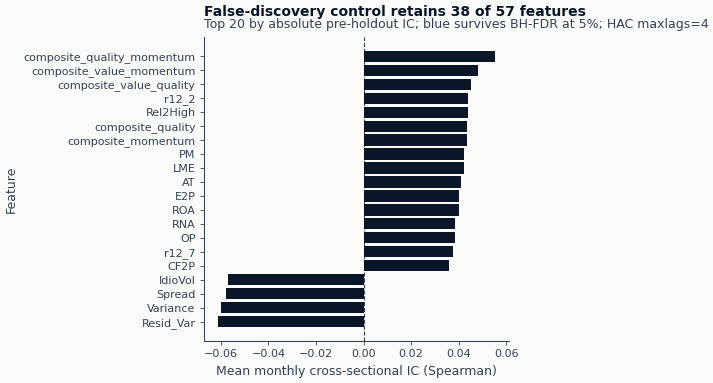

In [13]:
top_20 = eval_summary.drop_nulls("ic_mean").sort(pl.col("ic_mean").abs(), descending=True).head(20)
plot_top = top_20.sort("ic_mean")

fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"])
bar_colors = [
    COLORS["blue"] if significant else COLORS["silver_muted"]
    for significant in plot_top["significant_fdr05"].to_list()
]
ax.barh(plot_top["feature"].to_list(), plot_top["ic_mean"].to_list(), color=bar_colors)
zero_line(ax, at=0, axis="x")
ax.set_xlabel("Mean monthly cross-sectional IC (Spearman)")
ax.set_ylabel("Feature")
add_message_title(
    ax,
    f"False-discovery control retains {n_significant} of {len(feature_names)} features",
    subtitle=f"Top 20 by absolute pre-holdout IC; blue survives BH-FDR at 5%; HAC maxlags={HAC_MAXLAGS}",
)
fig.tight_layout()
plt.show()

### Feature Correlation Pairs

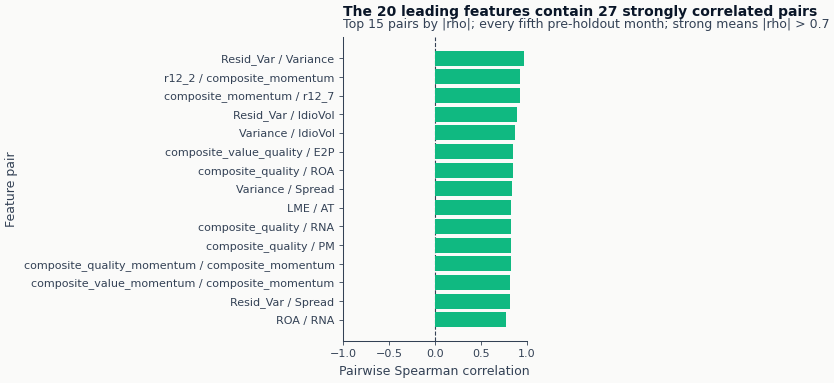

In [14]:
# Sample every fifth pre-holdout month for the descriptive redundancy view.
sample_dates = eval_df["timestamp"].unique().sort().to_list()
sample_dates = sample_dates[::5]

corr_data = eval_df.filter(pl.col("timestamp").is_in(sample_dates)).select(all_feature_cols)
corr_matrix = corr_data.to_pandas().corr(method="spearman")

display_cols = top_20["feature"].to_list()
display_corr = corr_matrix.loc[display_cols, display_cols]
display_high_corr = int(np.count_nonzero(np.triu(np.abs(display_corr.to_numpy()) > 0.7, k=1)))

pair_rows = []
for i, left in enumerate(display_cols):
    for right in display_cols[i + 1 :]:
        pair_rows.append(
            {
                "pair": f"{left} / {right}",
                "correlation": float(display_corr.loc[left, right]),
            }
        )
pair_summary = (
    pl.DataFrame(pair_rows)
    .with_columns(pl.col("correlation").abs().alias("abs_correlation"))
    .sort("abs_correlation", descending=True)
    .head(15)
    .sort("correlation")
)

fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"])
pair_colors = [
    COLORS["positive"] if value >= 0 else COLORS["negative"]
    for value in pair_summary["correlation"].to_list()
]
ax.barh(
    pair_summary["pair"].to_list(),
    pair_summary["correlation"].to_list(),
    color=pair_colors,
)
zero_line(ax, at=0, axis="x")
ax.set_xlim(-1, 1)
ax.set_xlabel("Pairwise Spearman correlation")
ax.set_ylabel("Feature pair")
add_message_title(
    ax,
    f"The 20 leading features contain {display_high_corr} strongly correlated pairs",
    subtitle="Top 15 pairs by |rho|; every fifth pre-holdout month; strong means |rho| > 0.7",
)
fig.tight_layout()
plt.show()

### Naive vs HAC t-Statistics

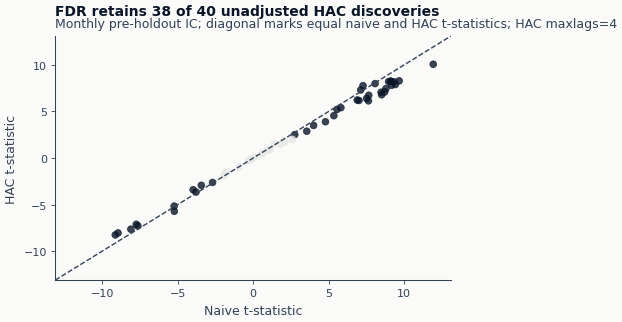

In [15]:
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
point_colors = [
    COLORS["blue"] if significant else COLORS["silver_muted"]
    for significant in eval_summary["significant_fdr05"].to_list()
]
ax.scatter(
    eval_summary["naive_tstat"].to_list(),
    eval_summary["hac_tstat"].to_list(),
    c=point_colors,
    s=24,
    alpha=0.8,
)
max_t = (
    max(
        abs(eval_summary["naive_tstat"].max() or 0),
        abs(eval_summary["hac_tstat"].max() or 0),
    )
    * 1.1
) or 1.0
ax.plot(
    [-max_t, max_t],
    [-max_t, max_t],
    linestyle="--",
    color=COLORS["neutral"],
    linewidth=1,
)
ax.set_xlim(-max_t, max_t)
ax.set_ylim(-max_t, max_t)
ax.set_xlabel("Naive t-statistic")
ax.set_ylabel("HAC t-statistic")
add_message_title(
    ax,
    f"FDR retains {n_significant} of {n_unadjusted_sig} unadjusted HAC discoveries",
    subtitle=f"Monthly pre-holdout IC; diagonal marks equal naive and HAC t-statistics; HAC maxlags={HAC_MAXLAGS}",
)
fig.tight_layout()
plt.show()

**Interpretation**: The comparison separates serial-dependence adjustment from
multiple-testing control. Features that survive BH-FDR have evidence against a
zero mean monthly IC within the development period; this is predictive evidence,
not a causal claim. Strong within-family correlations also warn that importance
can be shared across economically similar characteristics.

## 9. Feature Family Mapping

Assign each feature to its economic family and compute per-family average IC.

In [16]:
def assign_feature_family(feature_name: str) -> str:
    """Map feature to economic family using ALL_FAMILIES dict."""
    for family, members in ALL_FAMILIES.items():
        if feature_name in members:
            return family
    if feature_name.startswith("composite_"):
        return "composite"
    if feature_name.startswith("interaction_"):
        return "interaction"
    return "other"

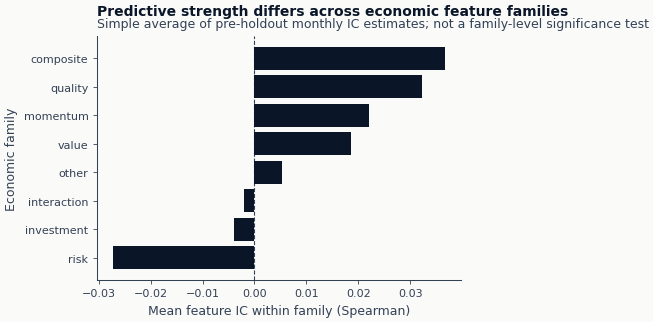

In [17]:
family_ic: dict[str, list[float]] = {}
for feat, stats in ic_results.items():
    family = assign_feature_family(feat)
    family_ic.setdefault(family, []).append(stats["mean_ic"])

family_avg_ic = {f: float(np.mean(ics)) for f, ics in family_ic.items()}

family_summary = pl.DataFrame(
    {
        "family": list(family_avg_ic),
        "mean_ic": list(family_avg_ic.values()),
        "n_features": [len(family_ic[family]) for family in family_avg_ic],
    }
).sort("mean_ic")

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.barh(
    family_summary["family"].to_list(),
    family_summary["mean_ic"].to_list(),
    color=COLORS["blue"],
)
zero_line(ax, at=0, axis="x")
ax.set_xlabel("Mean feature IC within family (Spearman)")
ax.set_ylabel("Economic family")
add_message_title(
    ax,
    "Predictive strength differs across economic feature families",
    subtitle="Simple average of pre-holdout monthly IC estimates; not a family-level significance test",
)
fig.tight_layout()
plt.show()

## 10. Save Feature Matrix

Save the complete feature matrix for downstream modeling chapters.
The matrix has schema: `(timestamp, symbol, feature_1, ..., feature_N)`.

In [18]:
# Select final output columns
output_df = features_df.select(["timestamp", "symbol"] + all_feature_cols)

# Drop rows where all features are null (shouldn't happen with this data)
output_df = output_df.drop_nulls(subset=feature_cols[:5])

print(f"\nFinal feature matrix: {len(output_df):,} rows x {len(all_feature_cols)} features")

FEATURES_DIR.mkdir(parents=True, exist_ok=True)
output_df.write_parquet(FEATURES_DIR / "financial.parquet")
print(f"Saved: {display_path(FEATURES_DIR / 'financial.parquet')}")

# Feature documentation
feature_doc = {
    "case_study_id": "us_firm_characteristics",
    "n_features": len(all_feature_cols),
    "families": {
        name: {
            "count": len([c for c in chars if c in all_feature_cols]),
            "features": [c for c in chars if c in all_feature_cols],
        }
        for name, chars in ALL_FAMILIES.items()
    },
    "composites": composite_cols,
    "interactions": interaction_cols,
    "pit_convention": (
        "Provider alignment: annual variables update at June end; monthly variables "
        "update at month-end for the following return month"
    ),
    "normalization": "Cross-sectional rank to [-0.5, 0.5] (source dataset)",
    "cost_note": {
        "pre_2001": "15-30 bps/leg (pre-decimalization spreads)",
        "post_2001": "5-15 bps/leg",
        "borrow": "25-100 bps/yr GC, up to 500+ bps for specials (D'Avolio 2002)",
    },
}
(FEATURES_DIR / "feature_doc.json").write_text(json.dumps(feature_doc, indent=2))
print("Saved: feature_doc.json")


Final feature matrix: 804,530 rows x 57 features


Saved: output/us_firm_signoff_20260721/us_firm_characteristics/features/financial.parquet
Saved: feature_doc.json


## Key Takeaways

1. The 46 released characteristics retain their provider-supplied cross-sectional
   rank normalization and persistent split-scoped anonymous firm identity.
2. Seven composites and four interactions expand the model matrix to 57 features
   without fitting a transform across time or across a validation boundary.
3. Monthly cross-sectional IC uses only observations before the 2016 holdout;
   Newey-West uncertainty allows up to four lags of serial dependence.
4. BH-FDR separates isolated low p-values from discoveries that survive the
   full 57-feature search; correlation diagnostics expose redundant signals.
5. Annual and monthly characteristics follow the provider's stated update
   conventions rather than an undocumented blanket lag.

**Next**: [`04_evaluation`](04_evaluation.ipynb) evaluates feature quality with
HAC-adjusted IC and FDR control before modeling begins.